Last Year in Dataset: 2024 

Monthly Sales & Profit (Last Year):

      Month  Total_Sales  Total_Profit
2   January      3707482        763909
1  February      3487176        689548
3     March      3614820        701993
0     April      3650140        730799
4       May       470464        100916 

HIGHEST SALES MONTH (DESCRIPTIVE ANALYSIS)
Year: 2024
Month: January
Total Sales: 3707482
Total Profit: 763909

In 2024, the highest sales were recorded in January with total sales of 3707482.00.


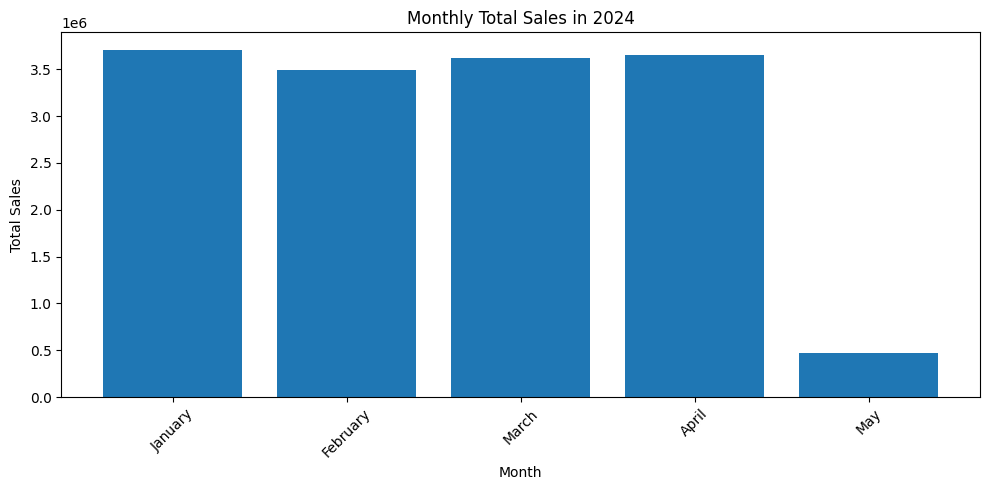

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("large_sales_data (1).csv")

date_col = next(col for col in df.columns if 'date' in col.lower())
df[date_col] = pd.to_datetime(df[date_col])

last_year = df[date_col].dt.year.max()
print("Last Year in Dataset:", last_year, "\n")

last_year_data = df[df[date_col].dt.year == last_year].copy()
last_year_data['Month'] = last_year_data[date_col].dt.month_name()

monthly_summary = (
    last_year_data
    .groupby('Month')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum')
    )
    .reset_index()
)

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_summary['Month'] = pd.Categorical(
    monthly_summary['Month'],
    categories=month_order,
    ordered=True
)

monthly_summary = monthly_summary.sort_values('Month')

print("Monthly Sales & Profit (Last Year):\n")
print(monthly_summary, "\n")

top_month = monthly_summary.loc[monthly_summary['Total_Sales'].idxmax()]

print("HIGHEST SALES MONTH (DESCRIPTIVE ANALYSIS)")
print("Year:", last_year)
print("Month:", top_month['Month'])
print("Total Sales:", top_month['Total_Sales'])
print("Total Profit:", top_month['Total_Profit'])

print(
    f"\nIn {last_year}, the highest sales were recorded in "
    f"{top_month['Month']} with total sales of "
    f"{top_month['Total_Sales']:.2f}."
)


plt.figure(figsize=(10, 5))
plt.bar(monthly_summary['Month'], monthly_summary['Total_Sales'])
plt.title(f"Monthly Total Sales in {last_year}")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()